# NorDex Shift Performance Analytics & Optimization

## Project Introduction
NorDex Manufacturing AS is a Bergen-based precision parts manufacturer founded in 1998, 
serving the **automotive** and **industrial equipment** sectors across Northern Europe. 
With **~1,000 employees** and revenues exceeding **€120 million**, the company runs 
three fully automated production plants across Norway.


### The Problem
Despite similar machinery, processes, and staffing across all shifts, NorDex faces a 
consistent performance imbalance across its three eight-hour shifts, Morning, Evening, 
and Night, with output variability of up to **25%**, an **8% OEE decline**, and a 
**29.6 percentage point** efficiency gap between the best and worst performing shifts.


### Objectives
- Analyze production output, machine health, operator skill mix, and downtime patterns
- Identify root causes of shift-level performance gaps through EDA
- Build predictive models to forecast shift efficiency scores
- Optimize workforce scheduling and machine allocation
- Track all experiments using MLflow for reproducibility

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Connecting to the SQL Database

In [3]:
import sqlite3

connection = sqlite3.connect('Shiftdata.db')
cursor = connection.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[]


In [4]:
import os
print(os.listdir('..'))


['LICENSE', 'requirements.txt', 'README.md', '.gitignore', 'nordex_env', 'ShiftData.db', '.git', 'notebooks']


In [5]:
import sqlite3
connection = sqlite3.connect('/Users/esther/Desktop/Nordex-Shift-Performance-Optimization/ShiftData.db')
Shift_Data = pd.read_sql("SELECT * FROM ShiftPerformance", connection)
Shift_Data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


### Basic Dataset Overview

1. **Column Inspection**
   - Listed and reviewed all column names using `Shift_Data.columns`

2. **Dataset Dimensions**
   - Determined the number of rows and columns using `Shift_Data.shape`

3. **Data Type Formatting**
   - Ensured each column is assigned the appropriate data type:
     - Dates formatted as `datetime`
     - Categorical fields formatted as `category`
     - Numerical values correctly formatted

4. **Duplicate Records Check**
   - Identified and quantified duplicate entries using `df.duplicated().sum()`

5. **Missing Values Assessment**
   - Detected and summarized missing values across all columns using `df.isna().sum()`

6. **Statistical Summary**
   - Examined the statistical distribution of numerical features using `df.describe()`:
     - Mean
     - Standard Deviation
     - Minimum
     - Maximum

In [6]:
# 1. Dataset Info - Overview of columns, non-null counts, data types and memory usage

Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

In [7]:
# 2. Column Inspection - List and review all column names

Shift_Data.columns

Index(['shift_id', 'shift_name', 'start_time', 'end_time', 'supervisor_id',
       'production_id', 'date', 'units_produced', 'defect_count',
       'cycle_time_avg', 'shift_efficiency_score', 'operator_id',
       'operator_name', 'experience_level', 'skill_category', 'machine_id',
       'runtime_hours', 'downtime_minutes', 'maintenance_flag',
       'machine_status', 'maintenance_id', 'issue_type',
       'maintenance_downtime', 'resolved_by', 'qc_id', 'defect_type',
       'severity', 'inspection_result', 'temperature', 'humidity',
       'timestamp'],
      dtype='object')

In [8]:
# 3. Dataset Dimensions - Number of rows and columns

Shift_Data.shape

(296334, 31)

In [9]:
##### Convert all columns with date-like values into an appropriate datetime data type to 
# ensure accurate time-based analysis and operations.

Shift_Data['date'] = pd.to_datetime(Shift_Data['date'])
Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])
Shift_Data['timestamp'] = pd.to_datetime(Shift_Data['timestamp'])

/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_3544/153272821.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['start_time'] = pd.to_datetime(Shift_Data['start_time'])
/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_3544/153272821.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Shift_Data['end_time'] = pd.to_datetime(Shift_Data['end_time'])


In [10]:
# Confirming the data types after conversion

Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334

In [11]:
# 5. Duplicate Records Check - Identify and count duplicate entries

Shift_Data.duplicated().sum()

np.int64(0)

In [12]:
# 6. Missing Values Assessment - Detect missing values across all columns

Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [13]:
# 7. Statistical Summary - Distribution of numerical features

Shift_Data.describe()

,shift_id,start_time,end_time,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,experience_level,runtime_hours,downtime_minutes,maintenance_flag,maintenance_id,maintenance_downtime,qc_id,temperature,humidity,timestamp
count,296334.000000,296334,296334,296334.000000,296334,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,296334.000000,115231.000000,115231.000000,296334.00000,295129.000000,295129.000000,295129
mean,2.048142,2026-05-28 14:23:06.478770688,2026-05-28 13:57:27.318228736,6777.751567,2024-02-14 16:00:58.312579584,634.718962,20.667409,36.018468,75.551615,4.059531,6.664388,50.130673,0.181711,937.577969,53.545726,138756.82872,20.901223,44.593118,2024-02-15 04:22:59.795276288
min,1.000000,2026-05-28 06:00:00,2026-05-28 06:00:00,1.000000,2024-01-01 00:00:00,414.000000,13.000000,32.000000,41.690033,1.000000,5.900000,10.000000,0.000000,1.000000,10.000000,1.00000,17.000000,30.000000,2024-01-01 08:00:00
25%,1.000000,2026-05-28 06:00:00,2026-05-28 06:00:00,3350.000000,2024-01-23 00:00:00,506.000000,18.000000,34.650000,64.280117,2.000000,6.430000,35.980000,0.000000,457.000000,38.300000,70076.25000,19.900000,38.700000,2024-01-23 08:00:00
50%,2.000000,2026-05-28 14:00:00,2026-05-28 14:00:00,6747.000000,2024-02-14 00:00:00,596.000000,21.000000,36.000000,75.963017,4.000000,6.620000,52.680000,0.000000,932.000000,55.840000,139062.50000,20.900000,44.500000,2024-02-15 00:00:00
75%,3.000000,2026-05-28 22:00:00,2026-05-28 22:00:00,10200.750000,2024-03-08 18:00:00,801.000000,23.000000,37.360000,87.208274,5.000000,6.900000,64.490000,0.000000,1414.000000,69.800000,207680.75000,21.900000,50.300000,2024-03-09 00:00:00
max,3.000000,2026-05-28 22:00:00,2026-05-28 22:00:00,13650.000000,2024-03-31 00:00:00,972.000000,29.000000,42.000000,104.379285,12.000000,7.330000,95.710000,1.000000,1897.000000,95.710000,276245.00000,25.000000,65.000000,2024-03-31 16:00:00
std,0.807365,NaN,NaN,3952.136116,NaN,152.655935,2.924631,1.969414,12.928116,2.437622,0.324082,19.454400,0.385606,549.669218,19.065400,79691.21252,1.524821,7.756084,NaN


## Filling Missing Values

- **`Shift_Data.isna().sum()`** - identifies how many missing values exist in each column
- **`Shift_Data.sort_values(by="date")`** - sorts the dataset chronologically to:
  - See trends over time
  - Spot anomalies in sequence
  - Enable accurate time-based calculations
- **Mean Imputation** - missing values are filled with the mean of their respective column

In [14]:
# Checking for trends over time, spot anomalies in sequence, and makes time-based calculations 

Shift_Data =Shift_Data.sort_values(by="date")

In [15]:
# Filling Temperature and Humidity columns with the mean value of each column
Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method='ffill').fillna(Shift_Data['temperature'].mean())
Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method='ffill').fillna(Shift_Data['humidity'].mean())

# Fill timestamp column with the mean value of the column
Shift_Data['timestamp'] = Shift_Data['timestamp'].fillna(method='ffill')

/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_3544/801928811.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['temperature'] = Shift_Data['temperature'].fillna(method='ffill').fillna(Shift_Data['temperature'].mean())
/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_3544/801928811.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['humidity'] = Shift_Data['humidity'].fillna(method='ffill').fillna(Shift_Data['humidity'].mean())
/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_3544/801928811.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Shift_Data['timestamp'] = Shift_Data['timestamp'].fillna(method='ffill')


In [16]:
Shift_Data.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

##  Handling Missing Values

The dataset has two groups of missing values, both structurally expected and handled
appropriately before analysis.

- Maintenance nulls filled with descriptive labels (`"No Issue"`, `"No Maintenance"`, `0`)
- `maintenance_id` dropped as it has no analytical value
- No missing values in any core production column


### Why This Matters
With nulls filled, the dataset is now complete and consistent. Maintenance-related
features can be used directly in the predictive model without risking errors from
missing values during training.

In [17]:
# Fill categorical columns 
Shift_Data['issue_type'] = Shift_Data['issue_type'].fillna("No Issue")
Shift_Data['resolved_by'] = Shift_Data['resolved_by'].fillna("No Maintenance")

# Filling downtime column
Shift_Data['maintenance_downtime'] = Shift_Data['maintenance_downtime'].fillna(0)

# DROPPING  maintenance_id  
Shift_Data = Shift_Data.drop(columns=['maintenance_id'])


In [18]:
Shift_Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 296334 entries, 0 to 296333
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                296334 non-null  int64         
 1   shift_name              296334 non-null  object        
 2   start_time              296334 non-null  datetime64[ns]
 3   end_time                296334 non-null  datetime64[ns]
 4   supervisor_id           296334 non-null  object        
 5   production_id           296334 non-null  int64         
 6   date                    296334 non-null  datetime64[ns]
 7   units_produced          296334 non-null  int64         
 8   defect_count            296334 non-null  int64         
 9   cycle_time_avg          296334 non-null  float64       
 10  shift_efficiency_score  296334 non-null  float64       
 11  operator_id             296334 non-null  object        
 12  operator_name           296334 non-

In [19]:
Shift_Data.isna().sum()

shift_id                  0
shift_name                0
start_time                0
end_time                  0
supervisor_id             0
production_id             0
date                      0
units_produced            0
defect_count              0
cycle_time_avg            0
shift_efficiency_score    0
operator_id               0
operator_name             0
experience_level          0
skill_category            0
machine_id                0
runtime_hours             0
downtime_minutes          0
maintenance_flag          0
machine_status            0
issue_type                0
maintenance_downtime      0
resolved_by               0
qc_id                     0
defect_type               0
severity                  0
inspection_result         0
temperature               0
humidity                  0
timestamp                 0
dtype: int64

## Exploratory Data Analysis (EDA)

#### Numerical Data Analysis
I examined and interpreted numerical data to uncover patterns, trends, and insights.

**Visualizations Created:**

- **Histograms** - to visualize the distribution of all numerical columns:
  - Units Produced
  - Defects
  - Cycle Time
  - Efficiency
  - Runtime
  - Downtime
  - Temperature
  - Humidity

- **Boxplots** - to identify outliers and understand the data spread for each numerical variable

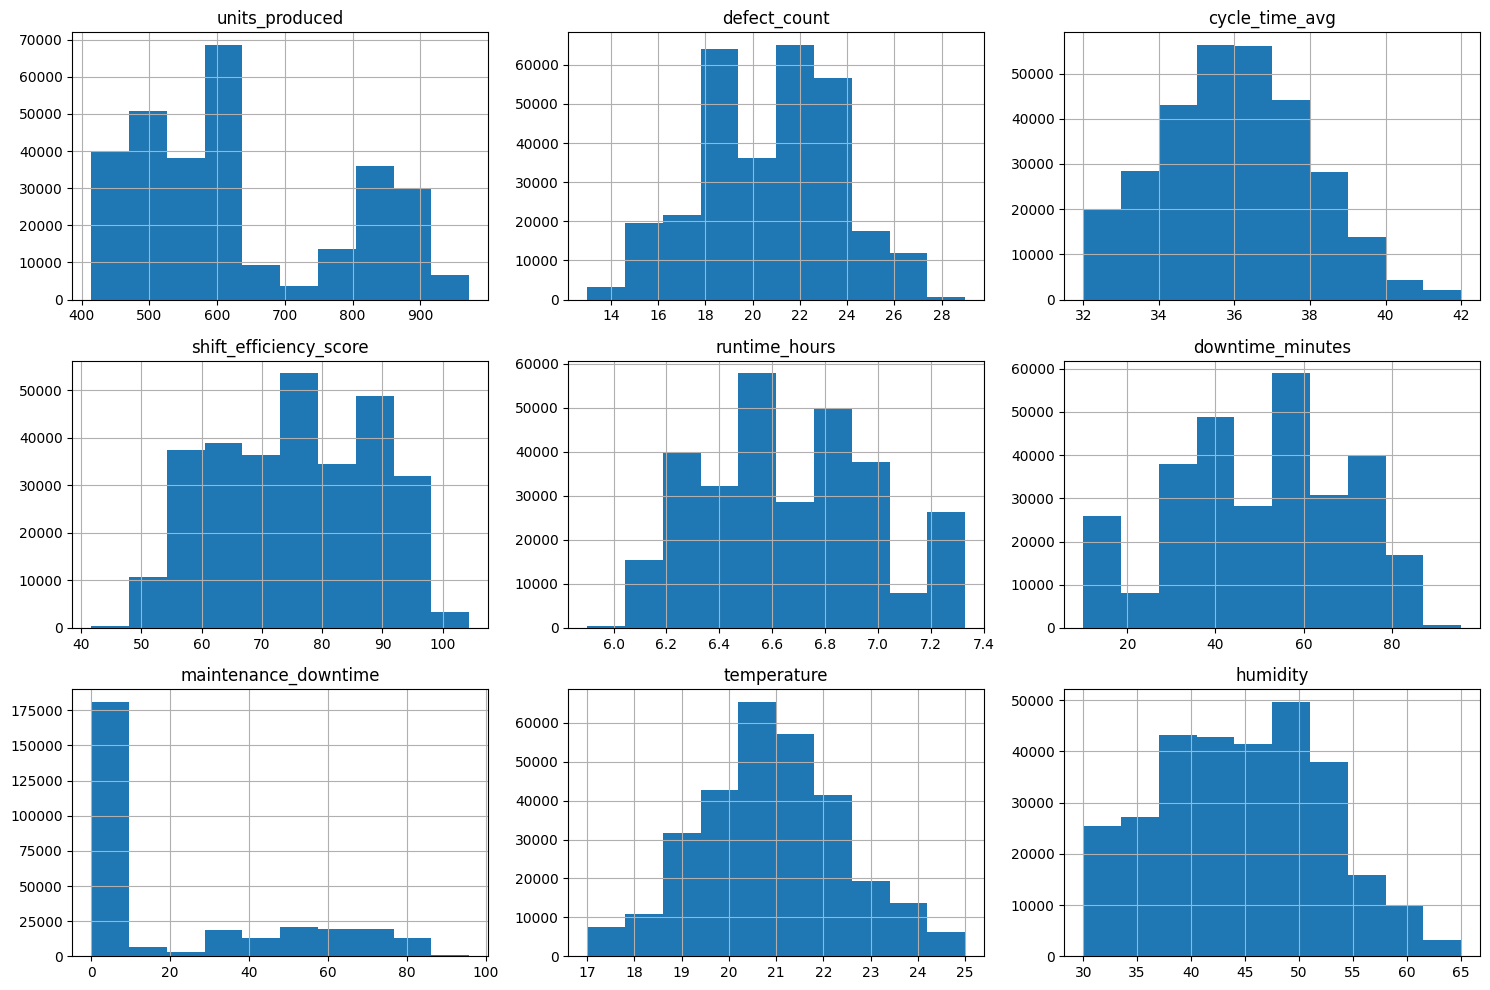

In [20]:
## Numerical Data Analysis

num_cols = [
    "units_produced", "defect_count", "cycle_time_avg", 
    "shift_efficiency_score", "runtime_hours", "downtime_minutes", "maintenance_downtime", 
    "temperature", "humidity"
]

Shift_Data[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

#### Numerical Variable Distributions Key Observations

The histograms shows the distribution of all nine numerical variables across
the full dataset. 

- `units_produced` and `shift_efficiency_score` show clear **bimodal distributions**
  — a direct visual signature of three distinct shift performance clusters
- `downtime_minutes` is right-skewed with a long tail toward 90+ minutes
- `cycle_time_avg`, `temperature`, and `humidity` show minimal variability
  and are not meaningful performance drivers

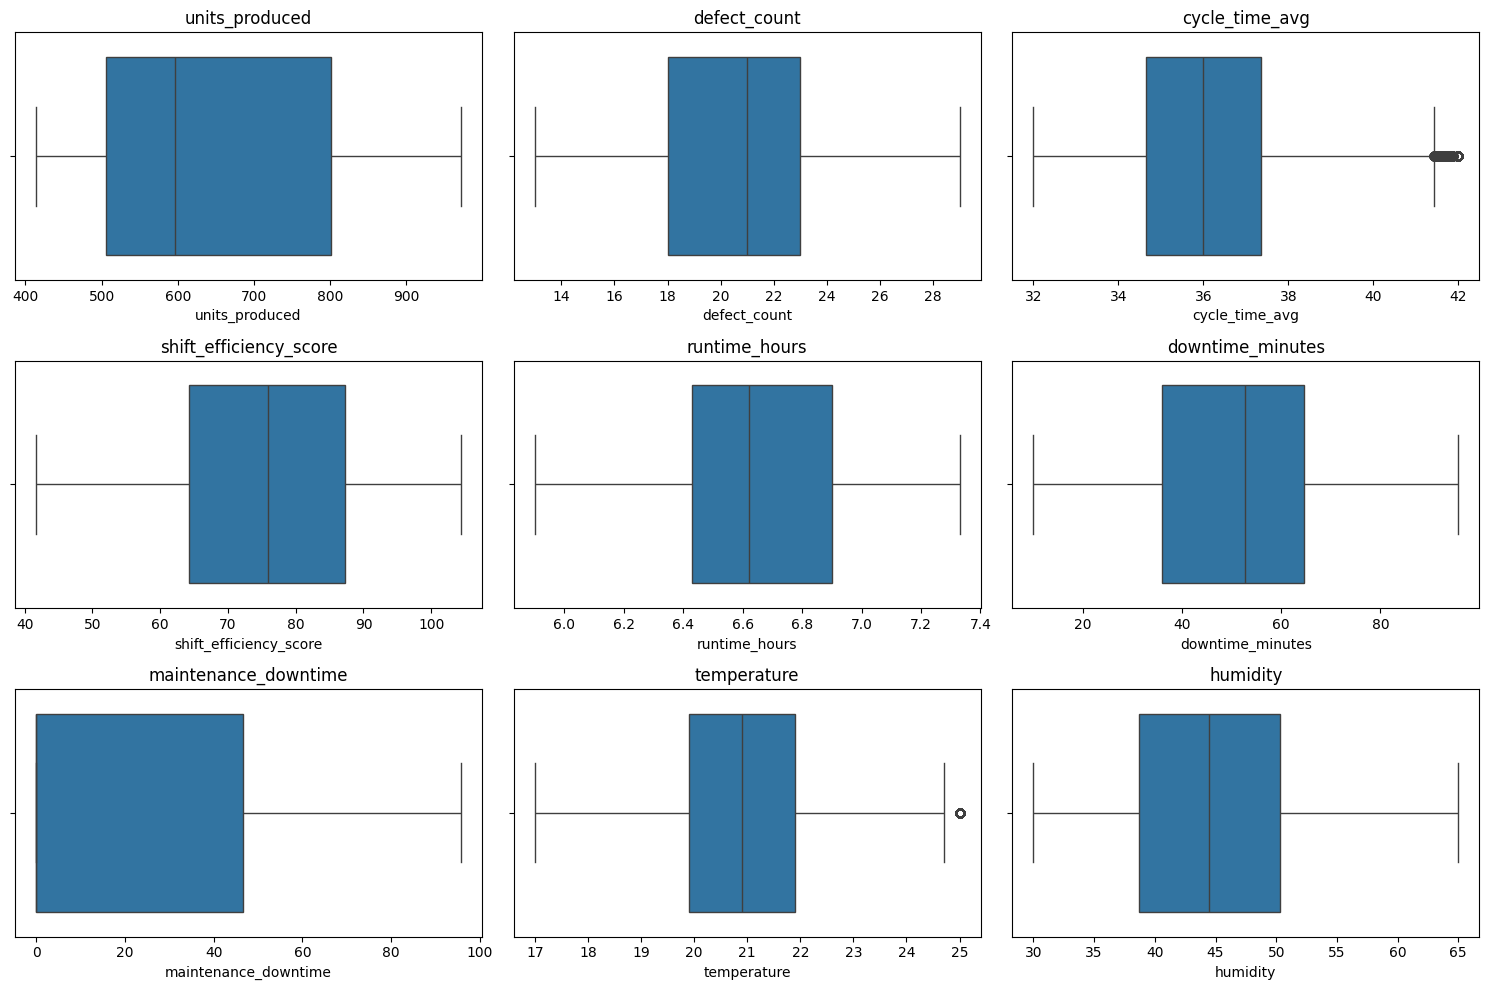

In [21]:
## Using the boxplot to check for outliers in the numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=Shift_Data[col])
    plt.title(col)
plt.tight_layout()
plt.show()


#### 📦 Outlier Detection (Boxplot Analysis) Key Observations

These boxplots show the spread and outliers for each numerical variable across
the full dataset without shift separation.

- No extreme or problematic outliers detected across any variable
- Wide spreads in `units_produced`, `shift_efficiency_score`, and
  `downtime_minutes` are not noise — they reflect the structural shift gap

#### Categorical Variables Analysis
I examined and interpreted categorical data to understand the frequency and distribution of each variable.

**Analysis Performed:**

- **Value Counts** - displayed value counts for all categorical columns:
  - Shift Name
  - Experience Level
  - Skill Category
  - Machine Status
  - Issue Type
  - Defect Type
  - Severity
  - Inspection Result

- **Bar Charts** - created in a 4x2 grid layout to visualize the frequency distribution of each categorical variable

In [22]:
# Categorical Data Analysis

Categorical_cols = ['shift_name', 'issue_type', 'resolved_by'
                    , 'machine_status', 'defect_type', 'inspection_result',
                    'severity', 'experience_level'
                    ]
for column in Categorical_cols:
    print(f"Value counts for {column}:\n")
    print(Shift_Data[column].value_counts())

Value counts for shift_name:

shift_name
Night      104057
Evening    102486
Morning     89791
Name: count, dtype: int64
Value counts for issue_type:

issue_type
No Issue       181103
Mechanical      40521
Electrical      28957
Calibration     18508
Software        16238
Preventive      11007
Name: count, dtype: int64
Value counts for resolved_by:

resolved_by
No Maintenance    181103
TECH_03            12537
TECH_07            12427
TECH_08            12290
TECH_02            12065
TECH_10            11977
TECH_05            11743
TECH_04            11275
TECH_01            10522
TECH_09            10441
TECH_06             9954
Name: count, dtype: int64
Value counts for machine_status:

machine_status
Issues         173712
Operational    122622
Name: count, dtype: int64
Value counts for defect_type:

defect_type
Dimensional    59777
Surface        59376
Assembly       59288
Cosmetic       59227
Material       58666
Name: count, dtype: int64
Value counts for inspection_result:

inspec

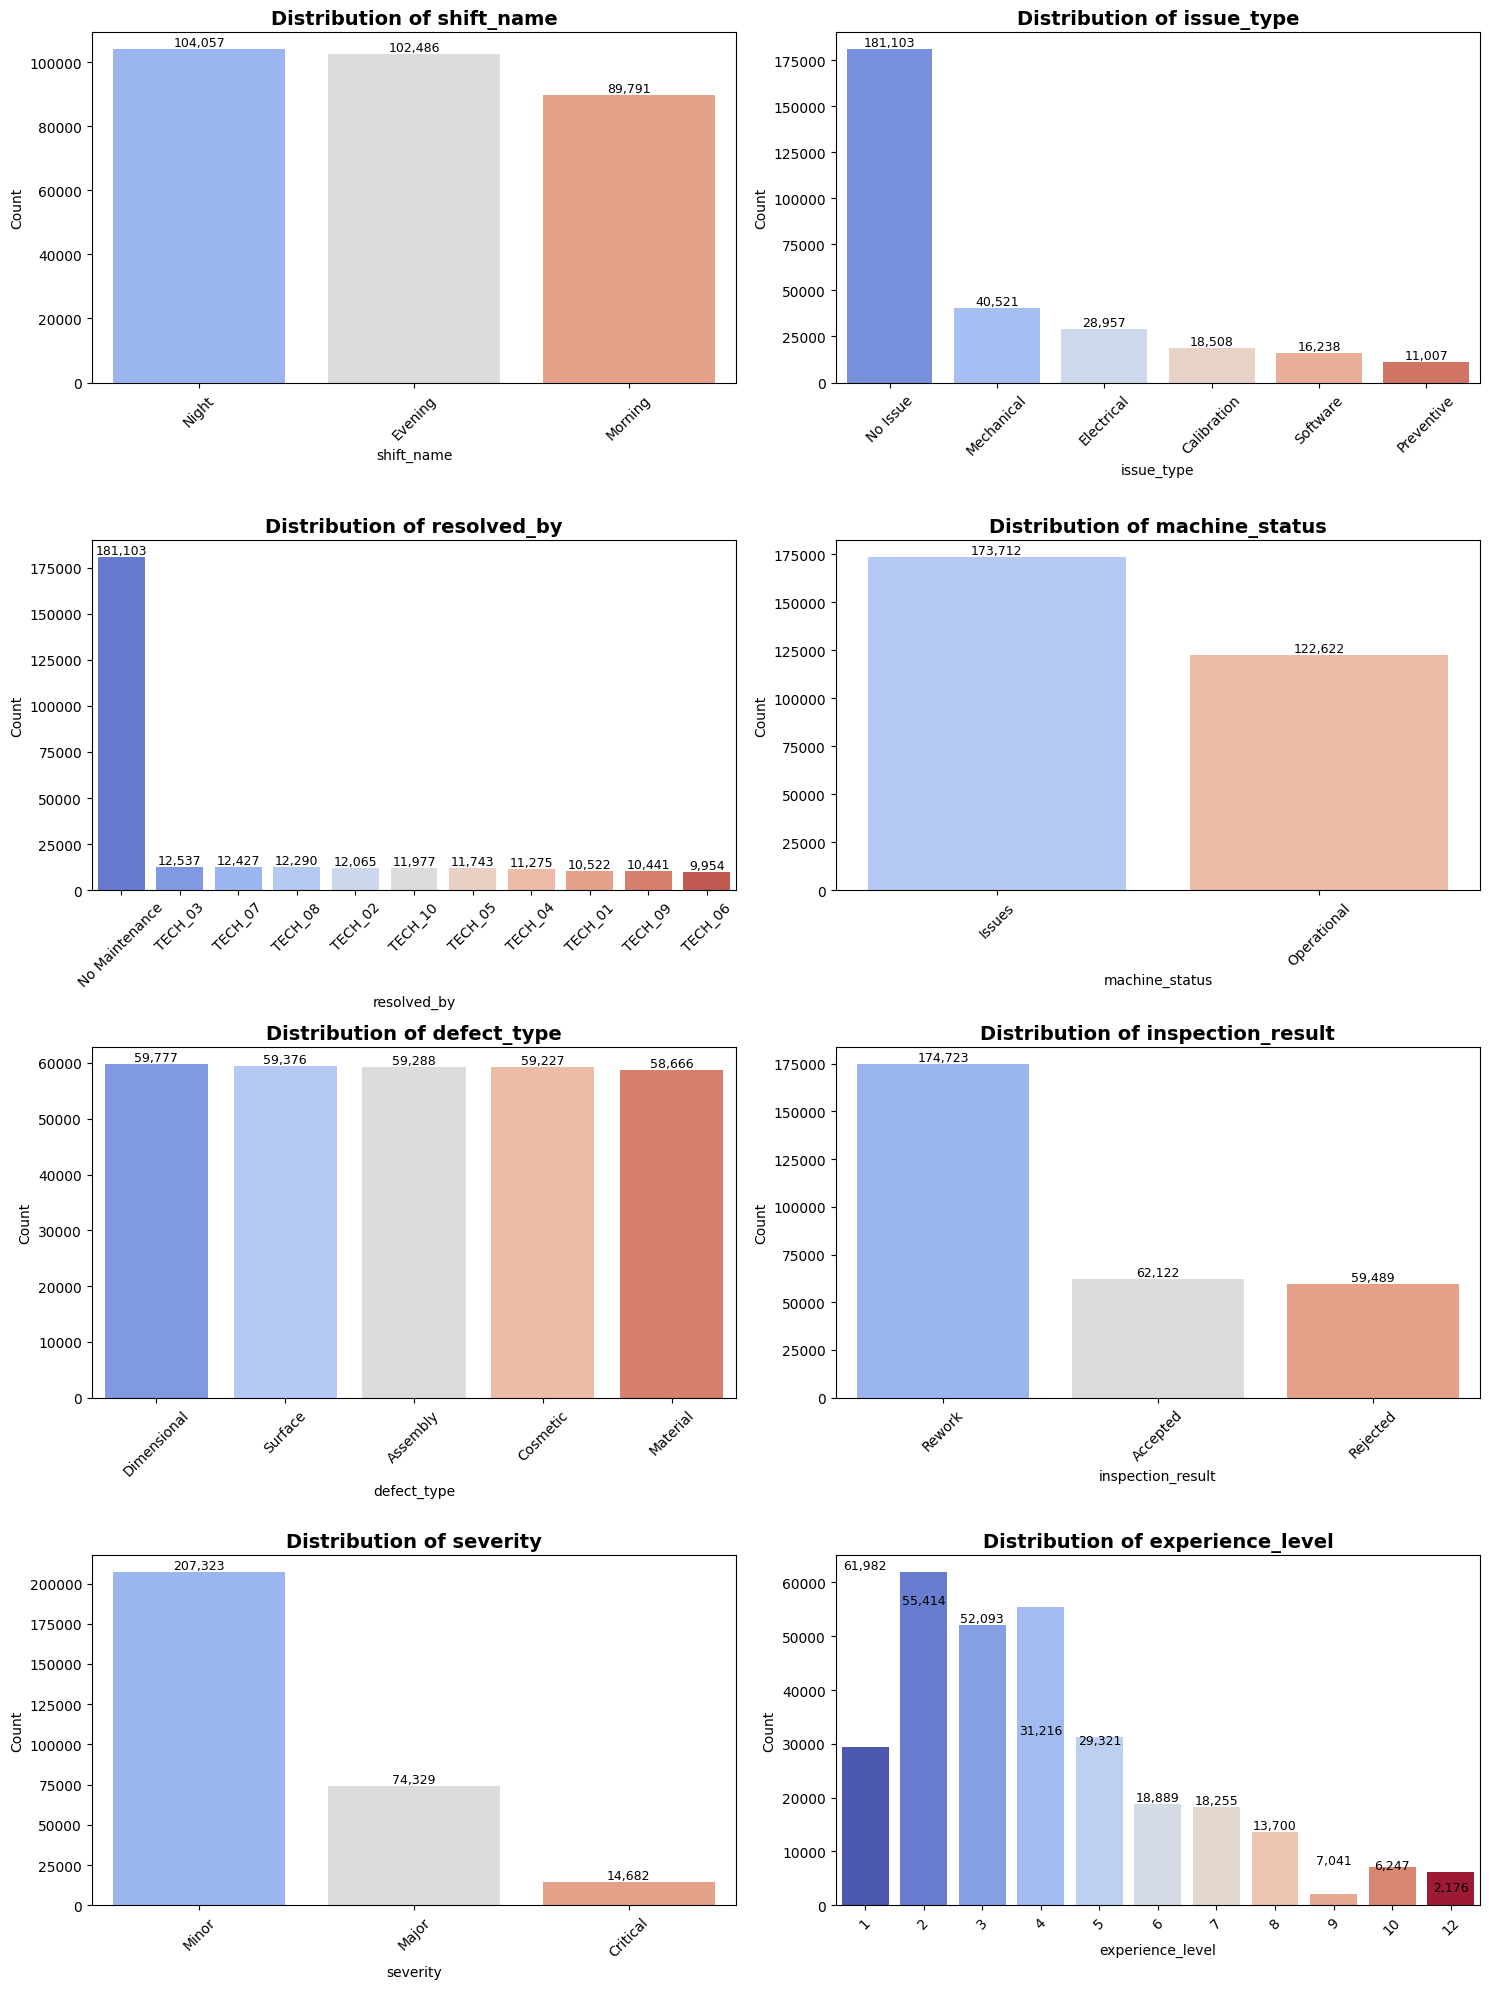

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

axes = axes.flatten()

for index, column in enumerate(Categorical_cols):
    # Get the value counts
    counts = Shift_Data[column].value_counts().reset_index()
    counts.columns = [column, 'count']

    sns.barplot(data=counts, x=column, y='count', palette="coolwarm", 
                ax=axes[index], hue=column, legend=False)

    # Plot customization
    axes[index].tick_params(axis='x', rotation=45)
    axes[index].set_title(f"Distribution of {column}", fontsize=14, fontweight='bold')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Count")

    # Add value labels on top of bars
    for j, v in enumerate(counts['count']):
        axes[index].text(j, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

#####  Categorical Variables Analysis Key Observation

- **machine_status**: 59% of records flagged with Issues, driven almost entirely
  by the Night shift (98.9% issues vs 3.5% on Morning)
- **issue_type**: Mechanical (35%) and Electrical (25%) account for 60% of all
  maintenance events
- **inspection_result**: 59% Rework rate consistent across all shifts — a
  systemic process issue, not a shift-specific one
- **defect_type** and **severity**: Evenly distributed across shifts, confirming
  neither is shift-driven
- **experience_level**: Levels 1 and 2 dominate the workforce. Expert operators
  (levels 10–12) are rare and concentrated on Morning shift


## Operational Performance During Maintenance vs No Maintenance

#### Maintenance Flag Analysis
I analyzed numerical metrics segmented by maintenance flag to compare performance across maintenance conditions.

**Analysis Performed:**

- **Grouped Metrics** - numerical metrics grouped by maintenance flag:
  - 0 = No Maintenance
  - 1 = Maintenance Performed

- **Grouped Bar Charts** - created to compare all metrics between the two maintenance flag categories

In [24]:
Shift_Data['maintenance_flag'].value_counts()

maintenance_flag
0    242487
1     53847
Name: count, dtype: int64

In [25]:
# Grouped Metrics

maintenance_data = Shift_Data.groupby("maintenance_flag")[num_cols].mean()
display(maintenance_data)

,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,runtime_hours,downtime_minutes,maintenance_downtime,temperature,humidity
maintenance_flag,,,,,,,,,
0,641.509524,20.593933,36.016664,76.106388,6.678512,49.281488,13.520254,20.900962,44.572548
1,604.139302,20.998291,36.026591,73.053327,6.600786,53.954773,53.701075,20.860356,44.613007


In [26]:
maintenance_data.head

<bound method NDFrame.head of                   units_produced  defect_count  cycle_time_avg  \
maintenance_flag                                                 
0                     641.509524     20.593933       36.016664   
1                     604.139302     20.998291       36.026591   

                  shift_efficiency_score  runtime_hours  downtime_minutes  \
maintenance_flag                                                            
0                              76.106388       6.678512         49.281488   
1                              73.053327       6.600786         53.954773   

                  maintenance_downtime  temperature   humidity  
maintenance_flag                                                
0                            13.520254    20.900962  44.572548  
1                            53.701075    20.860356  44.613007  >

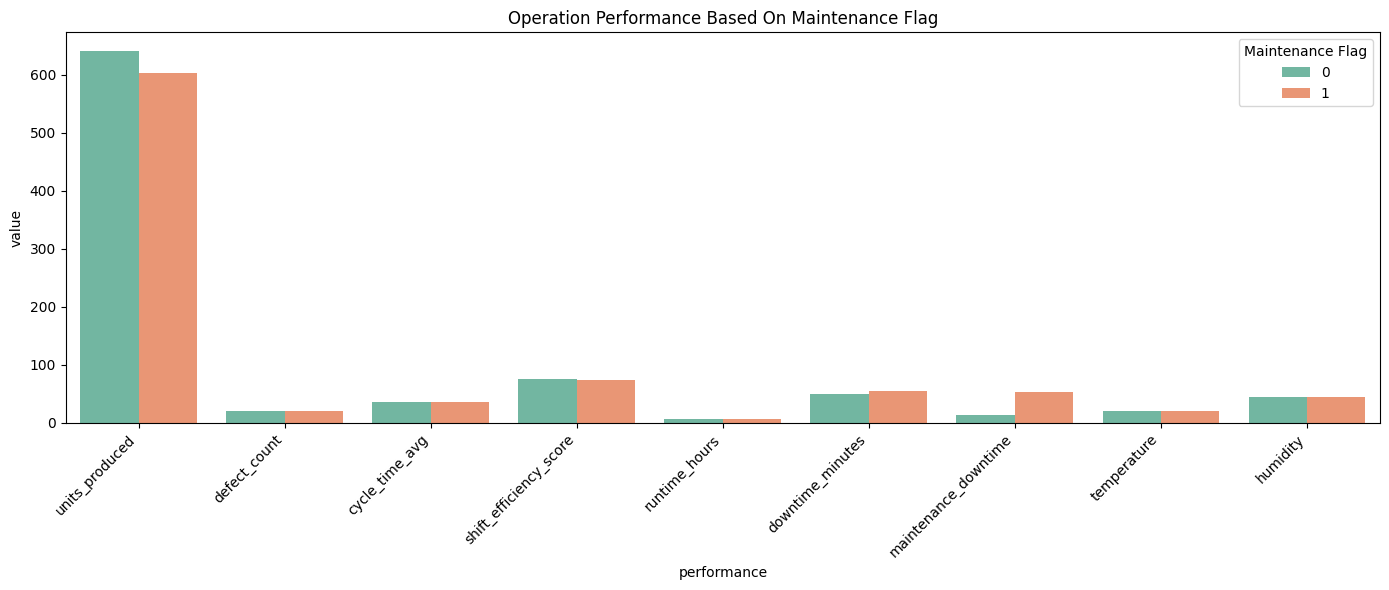

In [27]:
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars=['maintenance_flag'],
    var_name="performance",
    value_name='value'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=maintenance_plot_melt,
    x="performance",
    y="value",
    hue="maintenance_flag",
    palette="Set2"
)

plt.xticks(rotation=45, ha="right")
plt.title("Operation Performance Based On Maintenance Flag")
plt.legend(title="Maintenance Flag")
plt.tight_layout()
plt.show()

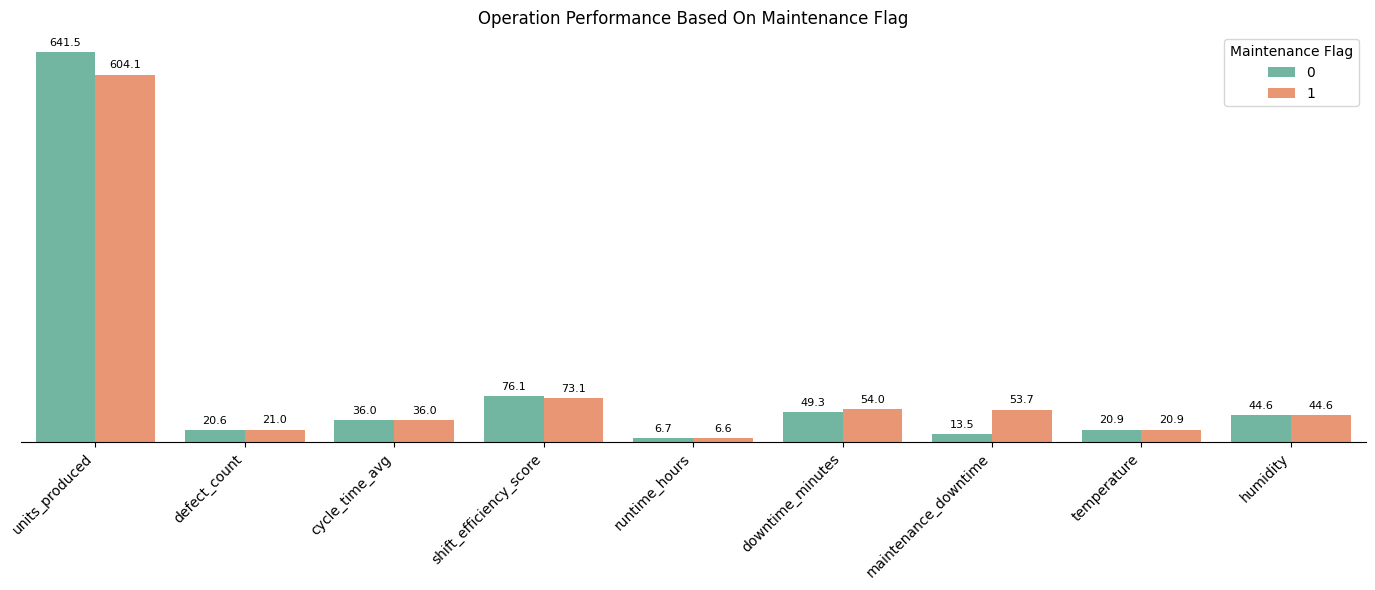

In [28]:
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars=['maintenance_flag'],
    var_name="performance",
    value_name='value'
)
plt.figure(figsize=(14, 6))
sns.barplot(
    data=maintenance_plot_melt,
    x="performance",
    y="value",
    hue="maintenance_flag",
    palette="Set2"
)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', padding=3, fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.title("Operation Performance Based On Maintenance Flag")
plt.ylabel("")
plt.xlabel("")
plt.legend(title="Maintenance Flag")
sns.despine(left=True)
plt.yticks([])
plt.tight_layout()
plt.show()

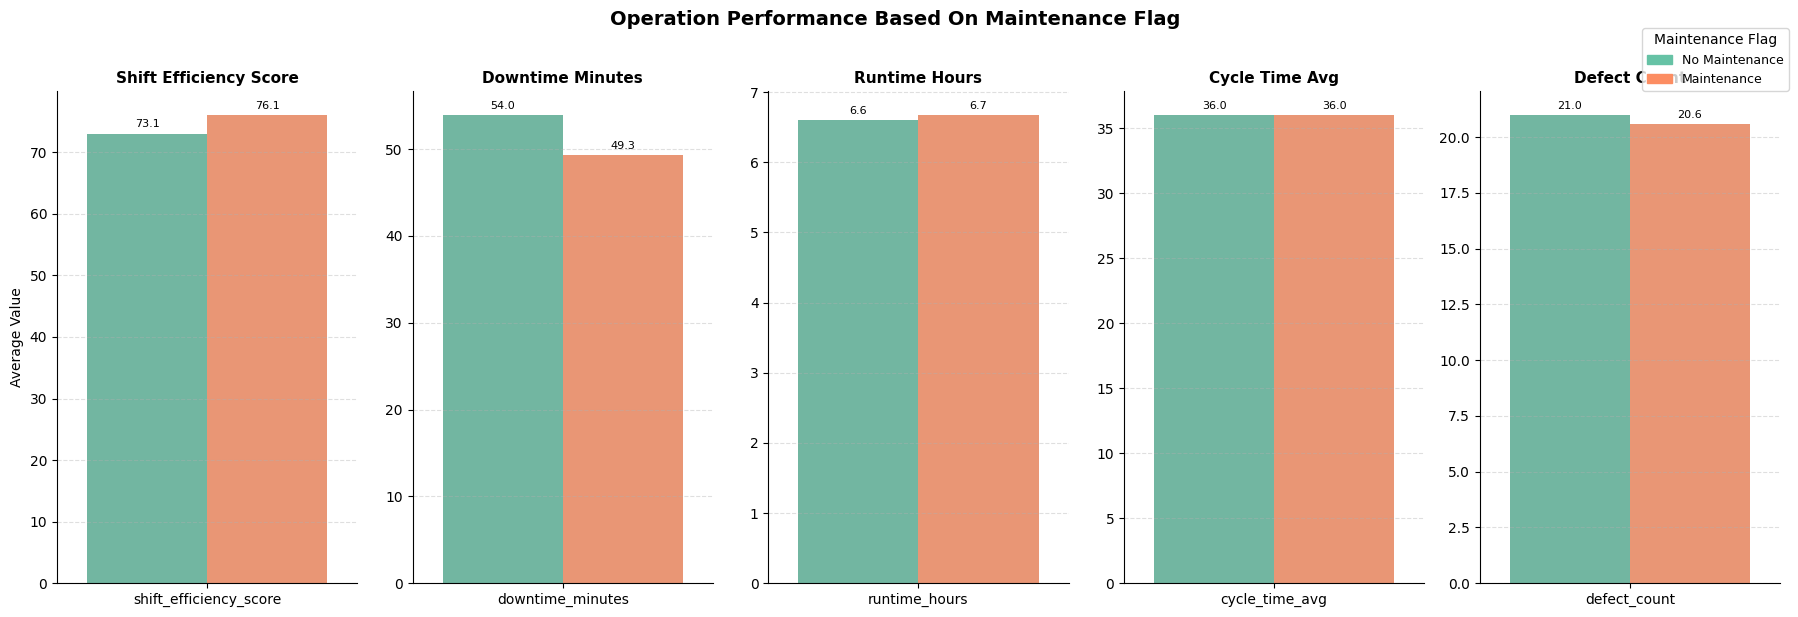

In [29]:
# Rename maintenance flag for cleaner legend
Shift_Data["maintenance_flag_label"] = Shift_Data["maintenance_flag"].map({
    0: "No Maintenance",
    1: "Maintenance"
})

maintenance_data = Shift_Data.groupby("maintenance_flag_label")[num_cols].mean()
maintenance_plot = maintenance_data.reset_index()
maintenance_plot_melt = maintenance_plot.melt(
    id_vars=["maintenance_flag_label"],
    var_name="performance",
    value_name="value"
)

metrics_to_plot = [
    "shift_efficiency_score", "downtime_minutes",
    "runtime_hours", "cycle_time_avg", "defect_count"
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 6))

for i, metric in enumerate(metrics_to_plot):
    subset = maintenance_plot_melt[maintenance_plot_melt["performance"] == metric]
    ax = sns.barplot(
        data=subset,
        x="performance",
        y="value",
        hue="maintenance_flag_label",
        palette="Set2",
        ax=axes[i],
        legend=False
    )
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.1f", padding=3, fontsize=8)
    axes[i].set_title(metric.replace("_", " ").title(), fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Average Value" if i == 0 else "")
    axes[i].grid(axis="y", linestyle="--", alpha=0.4)
    sns.despine(ax=axes[i])

# Build a single shared legend outside all subplots at top right
handles = [
    plt.Rectangle((0, 0), 1, 1, color=c)
    for c in sns.color_palette("Set2", 2)
]
labels = ["No Maintenance", "Maintenance"]

fig.legend(
    handles,
    labels,
    title="Maintenance Flag",
    fontsize=9,
    title_fontsize=10,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),
    frameon=True
)

plt.suptitle("Operation Performance Based On Maintenance Flag",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Shift Performance Analysis

This section computes and visualizes aggregated KPIs across the three NorDex shifts.
Each metric is grouped by shift and sorted from highest to lowest performing shift
(Morning → Evening → Night) to highlight the performance gap clearly.

**Metrics covered:**
- Units Produced (average and total)
- Cycle Time (average)
- Defect Count (average)
- Downtime in minutes (average and total)
- Shift Efficiency Score (average)
- Defect Rate (defects as a percentage of units produced)

In [30]:
shift_performance_data = Shift_Data.groupby("shift_name").aggregate({
    "units_produced": ["mean", "sum"],
    "cycle_time_avg": "mean",
    "defect_count": "mean",
    "downtime_minutes": ["mean", "sum"],
    "shift_efficiency_score": "mean"
}).reset_index()

shift_performance_data.columns = [
    "shift_name", "average_units_produced", "total_units_produced",
    "average_cycle_time", "average_defect_count", "average_downtime", "total_downtime",
    "average_efficiency"
]

# Calculate defect rate
defect_sum = Shift_Data.groupby("shift_name")["defect_count"].sum().values
units_sum = Shift_Data.groupby("shift_name")["units_produced"].sum().values

shift_performance_data["defect_rate"] = (defect_sum / units_sum) * 100

shift_performance_data.sort_values(by="average_units_produced", ascending=False)

,shift_name,average_units_produced,total_units_produced,average_cycle_time,average_defect_count,average_downtime,total_downtime,average_efficiency,defect_rate
1,Morning,846.926073,76046339,35.999287,18.749151,29.086002,2611661.18,90.869944,2.213788
0,Evening,601.050543,61599266,36.025551,21.329079,50.569570,5182672.96,76.737957,3.548633
2,Night,484.765119,50443204,36.028043,21.670998,67.857893,7061088.73,61.164965,4.470412


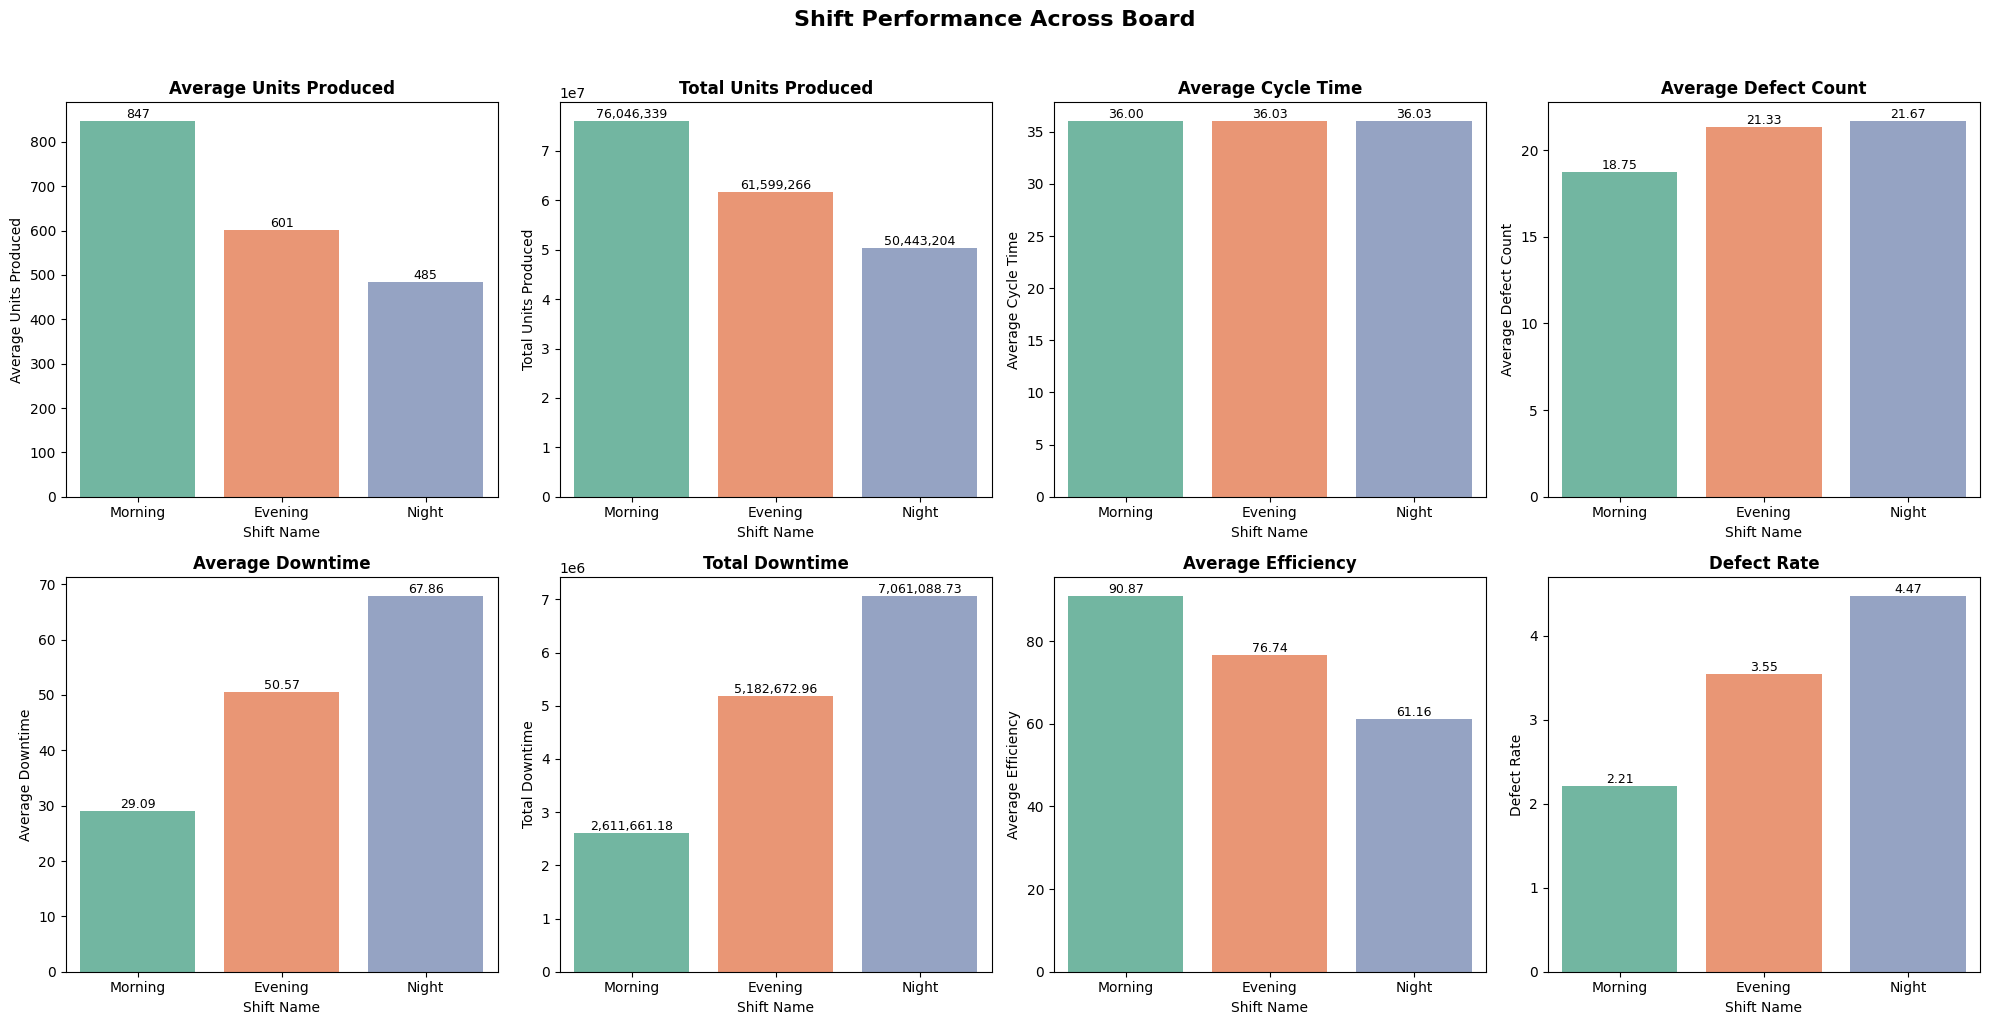

In [31]:
# Shift Performance Across Board

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes = axes.flatten()

metrics = [
    "average_units_produced", "total_units_produced",
    "average_cycle_time", "average_defect_count",
    "average_downtime", "total_downtime",
    "average_efficiency", "defect_rate"
]

shift_order = ["Morning", "Evening", "Night"]

for i, metric in enumerate(metrics):
    sns.barplot(
        data=shift_performance_data,
        x='shift_name',
        y=metric,
        hue='shift_name',
        order=shift_order,
        hue_order=shift_order,
        palette="Set2",
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(metric.replace("_", " ").title(), fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Shift Name")
    axes[i].set_ylabel(metric.replace("_", " ").title())

    for j, v in enumerate(shift_performance_data.set_index("shift_name").loc[shift_order, metric]):
        if 'units' in metric:
            axes[i].text(j, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
        else:
            axes[i].text(j, v, f'{v:,.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Shift Performance Across Board', fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#####  Operational Performance Based On Maintenance Flag Observations

Shifts with a maintenance event produce fewer units and run at lower efficiency,
not because maintenance is harmful, but because **machines are already failing
before anyone acts**. Downtime is higher, runtime is shorter, yet cycle time and
defect count remain unchanged — meaning the issue is availability, not process quality.

> The fix is simple: stop reacting to failures and start predicting them.
> Predictive maintenance would catch machine degradation before it costs
> production time.

## Shift Performance Based On Production Output Per Hour

In [33]:
Shift_Data["total_operation_hours"] = Shift_Data["runtime_hours"] + (Shift_Data["downtime_minutes"] / 60)

output_per_hour = (
    Shift_Data.groupby("shift_name")
    .apply(lambda x: x["units_produced"].sum() / x["total_operation_hours"].sum())
    .rename("output_per_hour")
)

output_per_hour

/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_3544/1906654872.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["units_produced"].sum() / x["total_operation_hours"].sum())


shift_name
Evening     80.140742
Morning    112.927525
Night       64.635285
Name: output_per_hour, dtype: float64

In [36]:
output_per_hour_data = output_per_hour.reset_index()

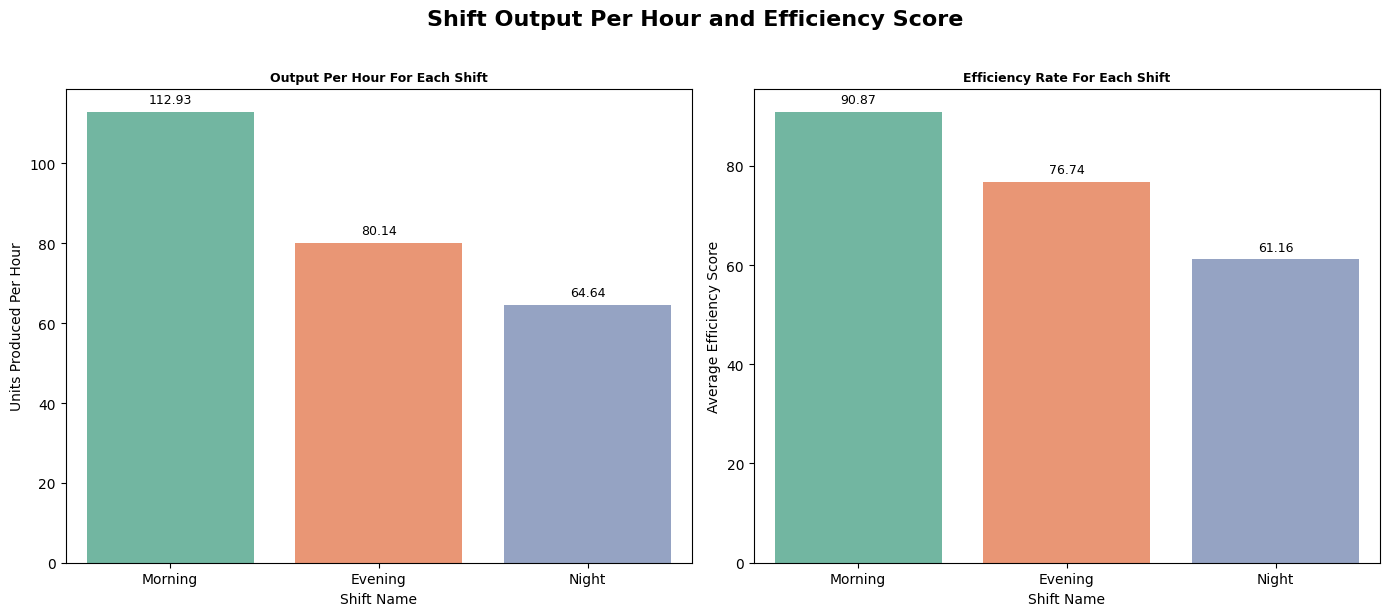

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
shift_order = ["Morning", "Evening", "Night"]

# Plot 1 - Output Per Hour

sns.barplot(
    data=output_per_hour_data,
    x="shift_name",
    y="output_per_hour",
    hue="shift_name",
    order=shift_order,
    hue_order=shift_order,
    palette="Set2",
    ax=axes[0],
    legend=False
)
axes[0].set_title("Output Per Hour For Each Shift", fontsize=9, fontweight="bold")
axes[0].set_xlabel("Shift Name")
axes[0].set_ylabel("Units Produced Per Hour")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=4, fontsize=9)

merged_data = shift_performance_data.merge(output_per_hour_data, on="shift_name")


# Plot 2 - Shift Efficiency Score

sns.barplot(
    data=merged_data,
    x="shift_name",
    y="average_efficiency",
    hue="shift_name",
    order=shift_order,
    hue_order=shift_order,
    palette="Set2",
    ax=axes[1],
    legend=False
)
axes[1].set_title("Efficiency Rate For Each Shift", fontsize=9, fontweight="bold")
axes[1].set_xlabel("Shift Name")
axes[1].set_ylabel("Average Efficiency Score")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=4, fontsize=9)

plt.suptitle("Shift Output Per Hour and Efficiency Score", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#####  Shift Performance — Output Per Hour & Efficiency Observations

Morning dominates both metrics. At **112.93 units per hour** and **90.87% efficiency**,
it outperforms Night shift by **75% in output** and **30 points in efficiency**.
The gap is structural and consistent, it is driven by operator experience and machine
health.

## OEE (Overall Equipment Effectiveness) Calculation

The code calculates Overall Equipment Effectiveness (OEE) by:

1. **Separating production and machine data** - Creates distinct tables for production metrics (units, defects) and machine metrics (downtime)

2. **Computing three OEE components:**
   - **Availability** - Machine uptime percentage
   - **Performance** - Speed efficiency vs theoretical maximum  
   - **Quality** - Percentage of defect-free units

3. **Tracking monthly trends** - Calculates OEE per month and identifies performance degradation between months

**Why this matters:** OEE is a manufacturing industry standard that pinpoints whether productivity losses come from equipment downtime, slow operation speeds, or product defects.

## A Detailed Breakdown of what is happening:


A simple scenario breakdown of the OEE code and why it is important:

---

## Code Breakdown: A Factory Story

### Meet Our Factory

Imagine you run a **bottle factory**. Each machine should produce **100 bottles per hour** (theoretical rate). Each shift is **7.5 hours** (planned time).

---

### First Code Block: Organizing the Data

**Scenario:** You have a messy notebook with all your factory records mixed together.

```python
prod = (
    df[['production_id', 'shift_id', 'date', 'units_produced', 'defect_count']]
    .drop_duplicates(subset=['production_id'])
    .copy()
)
```

**What's happening:** You create a clean **Production Log** that shows:
- How many bottles were made
- How many were defective
- One entry per production run (no duplicates)

```python
mach = (
    df[['machine_id', 'shift_id', 'date', 'downtime_minutes']]
    .drop_duplicates()
    .copy()
)
```

**What's happening:** You create a separate **Maintenance Log** that shows:
- How many minutes each machine broke down
- Organized by machine, shift, and date

**Why separate them?** Because one machine might break down during multiple production runs. Keeping them separate prevents counting the same breakdown twice.

---

### Second Code Block: Calculating OEE (The Scorecard)

**Scenario:** Now you want to grade how well your factory performed each day.

#### Step 1: Calculate Availability (Was the machine running?)

```python
mach['avail_machine'] = 1 - mach['downtime_minutes']/(PLANNED*60)
```

**Simple explanation:** 
- Perfect score = 1.0 (100% available)
- Each minute of breakdown reduces the score

**Example:** 
- Your shift is 7.5 hours = 450 minutes
- Machine broke down for 45 minutes
- Availability = 1 - (45 ÷ 450) = 0.90 or 90%
- **Meaning:** Machine was running 90% of the time

#### Step 2: Calculate Performance (Did it run at full speed?)

```python
merged['performance'] = (merged['units_produced'] / (THEO * PLANNED)).clip(0,1)
```

**Simple explanation:**
- Perfect score = 1.0 (100% speed)
- Slower production reduces the score

**Example:**
- Theoretical speed = 100 bottles per hour
- Planned time = 7.5 hours
- Should have made: 100 × 7.5 = 750 bottles
- Actually made: 600 bottles
- Performance = 600 ÷ 750 = 0.80 or 80%
- **Meaning:** Machine ran at 80% of its target speed

#### Step 3: Calculate Quality (Were the bottles good?)

```python
merged['quality'] = 1 - merged['defect_count']/merged['units_produced']
```

**Simple explanation:**
- Perfect score = 1.0 (100% good products)
- Each defective product reduces the score

**Example:**
- Made 600 bottles
- 30 were cracked (defects)
- Quality = 1 - (30 ÷ 600) = 0.95 or 95%
- **Meaning:** 95% of bottles were good, 5% were defective

#### Step 4: Calculate Final OEE Score

```python
merged['oee_est'] = merged['availability'] * merged['performance'] * merged['quality']
```

**Example calculation:**
- Availability = 90% (0.90)
- Performance = 80% (0.80)
- Quality = 95% (0.95)

**OEE = 0.90 × 0.80 × 0.95 = 0.684 or 68.4%**

**What this means for the factory owner:**

| Score | Grade | What It Tells You |
|-------|-------|-------------------|
| 68.4% | C | You're losing 31.6% of potential production |
| | | - 10% lost to breakdowns |
| | | - 20% lost to slow speed |
| | | - 5% lost to defects |

---

### Monthly Tracking: Spotting Problems Early

```python
monthly_oee = merged.groupby('month')['oee_est'].mean()
```

**Scenario:** You track OEE for three months:

| Month | OEE | Change |
|-------|-----|--------|
| Month 1 | 75% | Starting point |
| Month 2 | 70% | ↓ 5% |
| Month 3 | 65% | ↓ 10% total |

```python
degradation = (m1 - m3) / m1 * 100
```

**Result:** 13.3% degradation

**What this tells you:** Something is getting worse over time. Machines might be aging, maintenance might be slipping, or operators might be struggling.

---

### The Big Picture: Why This Matters

**Without OEE:** "Our factory isn't producing enough" (vague problem)

**With OEE:** 
- "Availability is 90%" → Breakdowns are minimal ✓
- "Performance is 60%" → Machines running too slow ✗
- "Quality is 95%" → Defects are fine ✓

**Action Plan:** Focus on improving machine speed (performance), not breakdowns or quality.

---

### Summary Table

| OEE Component | Question It Answers | Example Problem |
|---------------|---------------------|-----------------|
| **Availability** | Was the machine running? | Breakdowns, changeovers |
| **Performance** | Was it running at full speed? | Slow operation, jams |
| **Quality** | Did it make good products? | Defects, scrap |
| **OEE** | Overall factory health? | Combined score |

**Perfect Factory (100% OEE):** 
- Machine never stops (100% availability)
- Always runs at full speed (100% performance)
- Every product is perfect (100% quality)

**Real World:** Most factories score 60-85%. The code helps you find exactly where you're losing points.

In [45]:
production = (
    Shift_Data[["production_id", "shift_id", "date", "units_produced", "defect_count"]]
    .drop_duplicates(subset=["production_id"])
    .copy()
)

machine = (
    Shift_Data[["machine_id", "date", "shift_id", "downtime_minutes"]]
    .drop_duplicates()
    .copy()
)

In [46]:
production.head()

,production_id,shift_id,date,units_produced,defect_count
0,1,1,2024-01-01,929,20
2308,102,3,2024-01-01,530,21
2309,103,3,2024-01-01,489,22
2331,104,3,2024-01-01,527,21
2281,101,3,2024-01-01,555,21


In [48]:
production.shape

(13650, 5)

In [47]:
machine.head()

,machine_id,date,shift_id,downtime_minutes
0,MC_001,2024-01-01,1,15.39
2308,MC_002,2024-01-01,3,53.73
2309,MC_003,2024-01-01,3,51.90
2331,MC_004,2024-01-01,3,54.45
2281,MC_001,2024-01-01,3,52.99


In [49]:
machine.shape

(13650, 4)

### OEE Metrics Calculation


In [50]:
#### OEE Metrics Calculation

import os
PLANNED = globals().get('PLANNED_H', 7.5)
THEO = globals().get('THEO_RATE', 100.0)

## compute per machine availability
machine['available_machine'] = 1 - machine['downtime_minutes'] / (PLANNED * 60)
machine['available_machine'] = machine['available_machine'].clip(0,1)

available_machine_aggregate = (
machine.groupby(['date', 'shift_id'])['available_machine']
.mean()
.reset_index()
.rename(columns={'available_machine': 'machine_availability'})
)

In [52]:
available_machine_aggregate.head()

,date,shift_id,machine_availability
0,2024-01-01,1,0.963687
1,2024-01-01,2,0.920976
2,2024-01-01,3,0.881807
3,2024-01-02,1,0.965439
4,2024-01-02,2,0.919042


#### OEE Metrics — Machine Availability Observation

Machine availability decreases consistently across shifts every single day.
On the very first day of data (2024-01-01):

This pattern repeats daily throughout Q1 2024, confirming that machine
degradation is not random, it follows the shift cycle every single day
with no intra-day intervention to interrupt it.

In [54]:
available_machine_aggregate.shape

(273, 3)

In [59]:
# Merging availability into production
merged_production_data = production.merge(available_machine_aggregate, how='left', on=['date', 'shift_id'])
merged_production_data['machine_availability'] = merged_production_data['machine_availability'].fillna(1)

# Performance based on the planned time (not run time)
merged_production_data["performance"] = (merged_production_data['units_produced'] / (THEO * PLANNED)).clip(0, 1)

# Quality
merged_production_data["quality"] = 1 - (merged_production_data['defect_count'] / merged_production_data["units_produced"])
merged_production_data['quality'] = merged_production_data['quality'].fillna(1).clip(0, 1)

# Final OEE Estimate
merged_production_data["oee_est"] = (merged_production_data['machine_availability'] * merged_production_data['performance'] * merged_production_data['quality'])

merged_production_data["month"] = merged_production_data['date'].dt.month

In [60]:
merged_production_data.head()

,production_id,shift_id,date,units_produced,defect_count,machine_availability,performance,quality,oee_est,month
0,1,1,2024-01-01,929,20,0.963687,1.000000,0.978471,0.942940,1
1,102,3,2024-01-01,530,21,0.881807,0.706667,0.960377,0.598453,1
2,103,3,2024-01-01,489,22,0.881807,0.652000,0.955010,0.549072,1
3,104,3,2024-01-01,527,21,0.881807,0.702667,0.960152,0.594926,1
4,101,3,2024-01-01,555,21,0.881807,0.740000,0.962162,0.627846,1


#### OEE Metrics Calculation Observation

Morning hits **94.3% OEE** with performance at 100% of planned rate. Night drops
to **54.9 – 62.8% OEE**, driven primarily by performance collapsing to 65 – 74%
of planned rate. Quality holds steady across both shifts at 0.96+, pointing
directly to **operator experience as the root cause**, not the machines or
the process.

## Monthly OEE (Overall equipment effective for each of the month)

In [62]:
### Monthly OEE (Overall equipment effectiveness for each month)
monthly_oee = (
    merged_production_data.groupby('month')['oee_est']
    .mean()
    .sort_index()
)

# Print to confirm it matches the earlier value
for month, value in monthly_oee.items():
    print(f"Month {month} OEE: {value*100:.2f}%")

Month 1 OEE: 74.90%
Month 2 OEE: 68.53%
Month 3 OEE: 68.83%


In [63]:
# Calculating for month 1 to month 3

if 1 in monthly_oee.index and 3 in monthly_oee.index:
    m1 = monthly_oee.loc[1]
    m3 = monthly_oee.loc[3]
    degradation = (m1 - m3) / m1 * 100
    print(f"Quarterly degradation (month 1 -> month 3): {degradation:.2f}%")
else:
    print("Could not find month 1 and 3 in the data to compute the degradation process or curve.")

Quarterly degradation (month 1 -> month 3): 8.10%


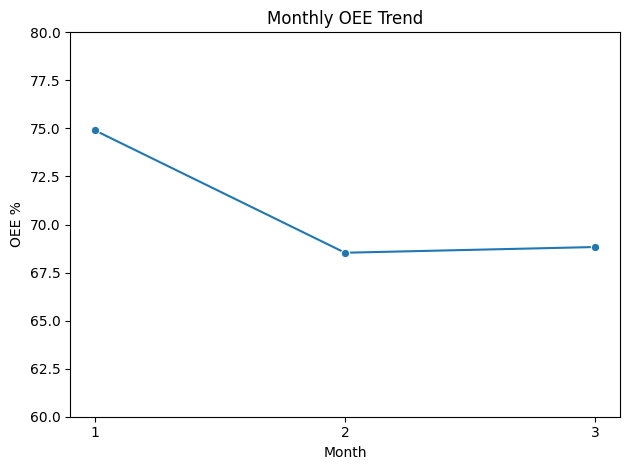

In [65]:
# Monthly OEE Trend

monthly_oee_df = monthly_oee.reset_index()
monthly_oee_df["OEE_percentage"] = monthly_oee_df['oee_est'] * 100

sns.lineplot(x='month', y='OEE_percentage', data=monthly_oee_df, marker="o")
plt.title("Monthly OEE Trend")
plt.ylabel("OEE %")
plt.ylim(60, 80)
plt.xticks([1, 2, 3])
plt.xlabel("Month")
plt.tight_layout()
plt.show()

##### Monthly OEE Trend — Q1 2024 Observation

OEE dropped from **75.0% in January** to **69.0% in February** and never
recovered. The flatline in March confirms this is not temporary and without
intervention, the decline will continue.

## Experience Vs the defects count that occure during production

/var/folders/lx/4f2b6hw90vdd1t756j_hmm7m0000gn/T/ipykernel_3544/2257102264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Shift_Data, x='experience_level', y='defect_count', palette='Set2')


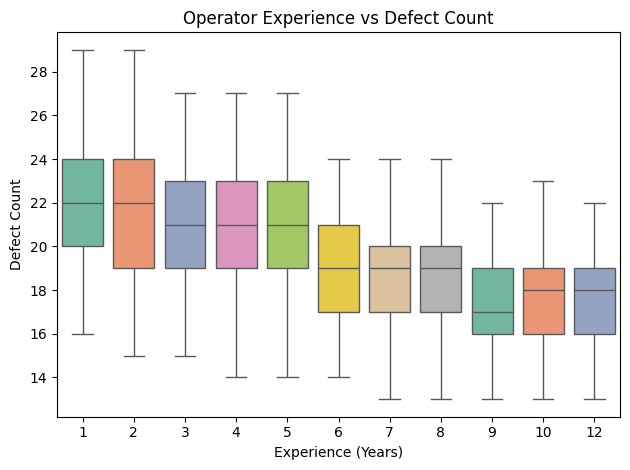

In [66]:
## Experience Vs the defects count that occur during production

sns.boxplot(data=Shift_Data, x='experience_level', y='defect_count', palette='Set2')
plt.title('Operator Experience vs Defect Count')
plt.xlabel('Experience (Years)')
plt.ylabel('Defect Count')
plt.tight_layout()
plt.show()

#####  Operator Experience vs Defect Count Observation

Defect count drops consistently as experience increases. Levels 1–5 produce
the most defects with wide, unpredictable spreads. Levels 9–12 produce the
fewest with the tightest distributions. More experienced operators are not
just better on average, they are more **consistent**. This directly explains
why the Night shift, staffed almost entirely with junior operators, carries
double the defect rate of Morning.